# Stat 220, Unit 1 Homework: Statistical Inference

Answer each problem in the cell(s) provided. Replace *Your answer* with your response
for written parts, and put code in the empty code cells.

The first problem is a **simulation lab**: you build a world where you already know the truth, so
you can watch the machinery work. The next three are **real data with real decisions attached**.
The last one asks what you are and are not entitled to conclude.

Throughout, a correct number with a wrong interpretation earns very little. Say what the number
means, and say what it does not mean.

**Data** (real, all from the course server):

- `https://richardson.byu.edu/220/bikes.csv`: 365 days of bike-rental counts with weather.
- `https://richardson.byu.edu/220/rent.csv`: 4,743 rental listings across six cities.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv")
print(bikes.shape, rent.shape)
bikes.head()

(365, 8) (4743, 9)


,Count,Temperature,Humidity,Wind_speed,Visibility,Rainfall,Seasons,Holiday
0,449,1.7,23,1.4,2000,0.0,Winter,No Holiday
1,479,4.3,41,1.3,1666,0.0,Winter,No Holiday
2,333,5.8,85,1.7,349,0.0,Winter,No Holiday
3,393,-0.3,38,4.8,1823,0.0,Winter,No Holiday
4,321,-2.3,25,0.0,1962,0.0,Winter,No Holiday


In [13]:
def welch_ci(x, y, confidence=0.95):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    diff = x.mean() - y.mean()
    se = np.sqrt(vx / nx + vy / ny)
    df = (vx / nx + vy / ny) ** 2 / (
        (vx / nx) ** 2 / (nx - 1) + (vy / ny) ** 2 / (ny - 1)
    )
    crit = stats.t.ppf(1 - (1 - confidence) / 2, df)
    return diff, diff - crit * se, diff + crit * se, df

**Problem 1.** *Simulation lab: what a p-value is.* Here you control the truth, so you can check
what the machinery does. Use `rng` for everything.

Part a. Write a function `run_studies(n_studies, n, true_diff, sd=1.0)` that simulates
`n_studies` experiments. Each experiment draws two independent groups of size `n` from normal
distributions whose means differ by `true_diff`, runs a Welch two-sample $t$-test, and returns the
array of p-values.

In [14]:
def run_studies(n_studies, n, true_diff, sd=1.0):
    pvals = []
    estimates = []
    for _ in range(n_studies):
        x = rng.normal(0, sd, n)
        y = rng.normal(true_diff, sd, n)
        result = stats.ttest_ind(y, x, equal_var=False)
        pvals.append(result.pvalue)
        estimates.append(y.mean() - x.mean())
    return np.asarray(pvals), np.asarray(estimates)


Part b. Run 5,000 studies with `true_diff = 0` and $n = 30$, so that **nothing is really
going on**. Plot a histogram of the p-values, and report the fraction below 0.05.

1b. Fraction with p < .05: 0.0488


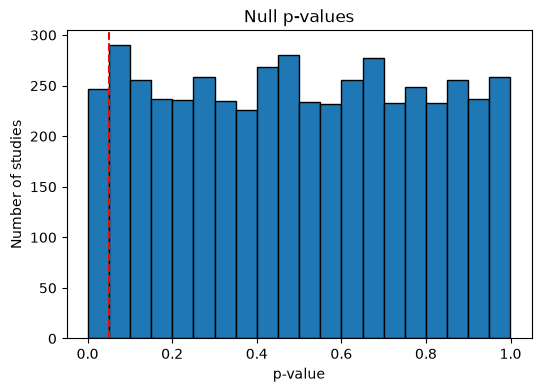

In [15]:
import numpy as np

rng = np.random.default_rng(220)
pvals, estimates = run_studies(5000, 30, 0)
print("1b. Fraction with p < .05:", np.mean(pvals < .05))

plt.figure(figsize=(6, 4))
plt.hist(pvals, bins=20, edgecolor="black")
plt.axvline(.05, color="red", linestyle="--")
plt.xlabel("p-value")
plt.ylabel("Number of studies")
plt.title("Null p-values")
plt.show()

Part c. The histogram should look flat. Explain in 2 to 3 sentences why the p-values are
uniform when the null is true, and what that implies about the meaning of "$p < 0.05$".


When the null hypothesis is true, valid p-values are uniformly distributed
between 0 and 1. Thus, p < .05 means that results this extreme would occur about
5% of the time under the null; it does not prove that a real effect exists.




Part d. Now set `true_diff = 0.5` and compute the fraction of studies that reach $p<0.05$
for $n = 10, 30, 100, 400$. This fraction is the **power**. Present the four numbers in a small
table and describe the pattern.

In [16]:
power_rows = []
for n in [10, 30, 100, 400]:
    ps, _ = run_studies(5000, n, .5)
    power_rows.append({"n": n, "power": np.mean(ps < .05)})
print("1d. Power table")
print(pd.DataFrame(power_rows).to_string(index=False))
print("Power increases with sample size because the standard error decreases.")


1d. Power table
  n  power
 10 0.2006
 30 0.4804
100 0.9458
400 1.0000
Power increases with sample size because the standard error decreases.


Part e. Keep $n = 15$ and `true_diff = 0.3`. Among only the studies that reached
significance, compute the average estimated difference. Compare it to the true 0.3 and explain the
phenomenon you have just measured, and why it makes small significant studies untrustworthy.

In [17]:
ps, est = run_studies(10000, 15, .3)
sig_est = est[ps < .05]
print("\n1e. Significant studies:", len(sig_est))
print("Average estimated difference among significant studies:", sig_est.mean())
print("True difference: 0.3")
print("""
The average among significant studies is usually larger than 0.3. This is
selection on unusually large estimates: small studies only become significant
when random variation exaggerates the observed effect, making significant small
studies especially vulnerable to overestimation.
""")


1e. Significant studies: 1230
Average estimated difference among significant studies: 0.8647019372048307
True difference: 0.3

The average among significant studies is usually larger than 0.3. This is
selection on unusually large estimates: small studies only become significant
when random variation exaggerates the observed effect, making significant small
studies especially vulnerable to overestimation.



Part f. Simulate the peeking problem: run experiments with **no real effect** where you
test after every 20 new observations up to $n = 500$ and stop the moment $p < 0.05$. Across 2,000
such experiments, what fraction produce a "significant" result? Explain the gap between that
number and 0.05.

In [18]:
peek_hits = 0
for _ in range(2000):
    x = rng.normal(0, 1, 500)
    stopped = False
    for n in range(20, 501, 20):
        if stats.ttest_1samp(x[:n], 0).pvalue < .05:
            stopped = True
            break
    peek_hits += stopped
print("1f. Fraction significant after peeking:", peek_hits / 2000)
print("""
Repeated testing creates many opportunities for a false positive. Therefore
the overall false-positive rate is greater than .05, even though each individual
test uses a .05 cutoff.
""")

1f. Fraction significant after peeking: 0.251

Repeated testing creates many opportunities for a false positive. Therefore
the overall false-positive rate is greater than .05, even though each individual
test uses a .05 cutoff.



**Problem 2.** *Real data: do holidays change bike ridership?* Use `bikes`. The operations team
wants to know whether to staff differently on holidays. `Count` is the day's rentals and `Holiday`
marks the day type.

Part a. Report the number of days, mean, and standard deviation of `Count` for each level
of `Holiday`. Plot the two distributions side by side (boxplot or overlaid histograms).

Holiday n = 18 mean = 621.6111111111111 SD = 587.3435850744473
No Holiday n = 347 mean = 703.4783861671469 SD = 421.79040554260195


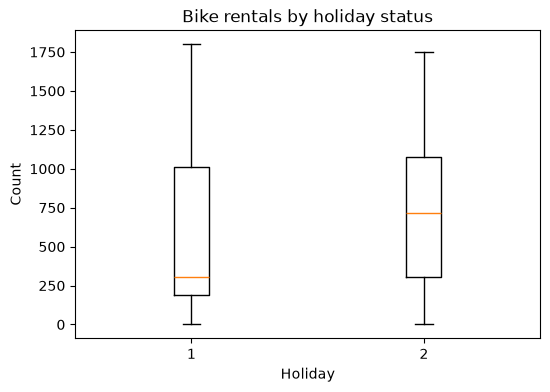

In [19]:
holiday_groups = list(bikes.groupby("Holiday")["Count"])
for label, values in holiday_groups:
    print(label, "n =", len(values), "mean =", values.mean(),
          "SD =", values.std(ddof=1))

plt.figure(figsize=(6, 4))
plt.boxplot([v for _, v in holiday_groups],)
plt.xlabel("Holiday")
plt.ylabel("Count")
plt.title("Bike rentals by holiday status")
plt.show()

Part b. Run a Welch two-sample $t$-test comparing the two groups. Report the difference in
means, the $t$-statistic, the p-value, and a 95% confidence interval for the difference.

In [20]:
h1, h2 = holiday_groups[0][1], holiday_groups[1][1]
d, lo, hi, df = welch_ci(h2, h1)
test = stats.ttest_ind(h2, h1, equal_var=False)
print("2b. Difference in means (second group - first group):", d)
print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)
print("95% CI:", (lo, hi))

2b. Difference in means (second group - first group): 81.86727505603585
t-statistic: 0.5836085356740244
p-value: 0.5667571158807455
95% CI: (np.float64(-212.9383180838738), np.float64(376.6728681959455))


Part c. The result is not significant. Your manager writes: *"Confirmed, holidays make no difference. Staff them normally."* Using your confidence interval, explain in 3 to 4 sentences
why that conclusion is not supported, and what the data actually establishes.

A non-significant result does not confirm that holidays have no effect.
The confidence interval gives the range of differences reasonably compatible
with the data, including effects that may matter operationally. The data do not
establish exact equality; they show only that this sample did not provide strong
evidence of a difference.




Part d. Quantify the problem: by simulation, estimate the power this comparison would have
to detect a true difference of 150 rentals per day, given the group sizes and standard deviations
you observed. (Simulate from normals with those parameters and count how often $p<0.05$.) What
does the number tell you?

In [21]:
n_h, n_non = len(h1), len(h2)
sd_h, sd_non = h1.std(ddof=1), h2.std(ddof=1)
power = []
for _ in range(10000):
    a = rng.normal(h1.mean(), sd_h, n_h)
    b = rng.normal(h2.mean() + 150, sd_non, n_non)
    power.append(stats.ttest_ind(b, a, equal_var=False).pvalue < .05)
print("2d. Estimated power for a 150-rental difference:", np.mean(power))
print("Low power means this comparison may miss a practically important effect.")

2d. Estimated power for a 150-rental difference: 0.344
Low power means this comparison may miss a practically important effect.


Part e. How many holidays would you need in the data to reach 80% power against a
150-rental difference? Find it by simulating a range of holiday counts. Given that a year contains
a fixed number of holidays, what does your answer imply about ever settling this question with one
year of data?

In [22]:

holiday_power = []
for nh in range(5, 101, 5):
    hits = []
    for _ in range(2000):
        a = rng.normal(h1.mean(), sd_h, nh)
        b = rng.normal(h2.mean() + 150, sd_non, n_non)
        hits.append(stats.ttest_ind(b, a, equal_var=False).pvalue < .05)
    holiday_power.append((nh, np.mean(hits)))

power_df = pd.DataFrame(holiday_power, columns=["holiday_n", "power"])
print("2e. Simulated holiday-count power:")
print(power_df.to_string(index=False))
needed = power_df.loc[power_df.power >= .8, "holiday_n"]
print("First tested holiday count reaching 80% power:",
      int(needed.iloc[0]) if len(needed) else "not reached")
print("""
If the required number exceeds the number of holidays available in one year,
one year cannot reliably settle the question. More years or a designed study
would be needed.
""")

2e. Simulated holiday-count power:
 holiday_n  power
         5 0.1190
        10 0.1905
        15 0.3045
        20 0.3800
        25 0.4535
        30 0.5380
        35 0.6235
        40 0.6610
        45 0.7140
        50 0.7375
        55 0.7970
        60 0.8260
        65 0.8465
        70 0.8800
        75 0.8910
        80 0.9145
        85 0.9170
        90 0.9495
        95 0.9425
       100 0.9515
First tested holiday count reaching 80% power: 60

If the required number exceeds the number of holidays available in one year,
one year cannot reliably settle the question. More years or a designed study
would be needed.



**Problem 3.** *Real data: furnished apartments rent for more.* Use `rent`. A property manager
asks how much extra to charge for furnishing a unit.

Part a. Compare `Rent` for `FurnishingStatus == "Furnished"` versus `"Unfurnished"`.
Report both sample sizes, both means, the difference, the $t$-statistic, and the p-value.

In [23]:
furnished = rent.loc[rent["FurnishingStatus"] == "Furnished", "Rent"].dropna()
unfurnished = rent.loc[rent["FurnishingStatus"] == "Unfurnished", "Rent"].dropna()

test = stats.ttest_ind(furnished, unfurnished, equal_var=False)
d, lo, hi, df = welch_ci(furnished, unfurnished)

print("3a. Furnished n, mean:", len(furnished), furnished.mean())
print("Unfurnished n, mean:", len(unfurnished), unfurnished.mean())
print("Difference:", d)
print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)



3a. Furnished n, mean: 679 56170.85125184094
Unfurnished n, mean: 1813 22480.07115278544
Difference: 33690.7800990555
t-statistic: 10.513973395325348
p-value: 2.9025866170815548e-24


Part b. The p-value is astronomically small. Explain what that does and does not tell you.
In particular, state whether it says anything about **how much** furnishing is worth.


A very small p-value provides strong evidence that the group means differ.
It does not measure the size or practical value of the difference, and it does
not establish that furnishing caused the difference.




Part c. Report a 95% confidence interval for the difference in mean rent, and compare the
information it carries to the p-value from Part a. Which would you put in a memo, and why?

In [24]:
print("3c. 95% CI for furnished minus unfurnished:", (lo, hi))
print("""
The confidence interval communicates both uncertainty and the plausible size of
the difference, so it is more useful in a manager's memo than the p-value alone.
""")

3c. 95% CI for furnished minus unfurnished: (np.float64(27400.504081386018), np.float64(39981.056116724976))

The confidence interval communicates both uncertainty and the plausible size of
the difference, so it is more useful in a manager's memo than the p-value alone.



Part d. Furnished units are not otherwise identical to unfurnished ones. Compare the two
groups on `Size`, `BHK`, and `City` composition. Report at least two ways they differ.

In [25]:
comparison = rent.groupby("FurnishingStatus").agg(
    n=("Rent", "size"),
    mean_size=("Size", "mean"),
    mean_bhk=("BHK", "mean")
)
print("3d. Group comparisons:")
print(comparison)
print("\nCity composition:")
print(pd.crosstab(rent["City"], rent["FurnishingStatus"], normalize="columns"))

3d. Group comparisons:
                     n    mean_size  mean_bhk
FurnishingStatus                             
Furnished          679  1047.456554  2.169367
Semi-Furnished    2251  1077.342959  2.200800
Unfurnished       1813   801.703806  1.907887

City composition:
FurnishingStatus  Furnished  Semi-Furnished  Unfurnished
City                                                    
Bangalore          0.134021        0.259440     0.116382
Chennai            0.117820        0.199023     0.199669
Delhi              0.142857        0.123501     0.126862
Hyderabad          0.163476        0.178587     0.194705
Kolkata            0.089838        0.063083     0.177055
Mumbai             0.351988        0.176366     0.185328


Part e. Repeat the furnished-versus-unfurnished comparison **within a single city and a
single `BHK` level** (choose ones with enough listings). Report the difference and its interval.
How does it compare to the raw difference from Part a, and what does that tell the property
manager about the number they should actually use?

In [26]:
city_counts = rent.groupby(["City", "BHK", "FurnishingStatus"]).size().unstack(fill_value=0)
eligible = city_counts[
    (city_counts.get("Furnished", 0) >= 20) &
    (city_counts.get("Unfurnished", 0) >= 20)
]
if len(eligible):
    chosen_city, chosen_bhk = eligible.index[0]
    subset = rent[(rent.City == chosen_city) & (rent.BHK == chosen_bhk)]
    f = subset.loc[subset.FurnishingStatus == "Furnished", "Rent"].dropna()
    u = subset.loc[subset.FurnishingStatus == "Unfurnished", "Rent"].dropna()
    d2, lo2, hi2, _ = welch_ci(f, u)
    print(f"\n3e. Within city={chosen_city}, BHK={chosen_bhk}:")
    print("Difference:", d2)
    print("95% CI:", (lo2, hi2))
    print("""
Controlling for city and bedroom count can substantially change the raw
difference. The manager should use a comparison among genuinely comparable
units rather than automatically using the unadjusted difference.
""")
else:
    print("3e. No city/BHK stratum had at least 20 listings in both groups.")



3e. Within city=Bangalore, BHK=2:
Difference: 4549.25
95% CI: (np.float64(1146.5340557092877), np.float64(7951.965944290712))

Controlling for city and bedroom count can substantially change the raw
difference. The manager should use a comparison among genuinely comparable
units rather than automatically using the unadjusted difference.



**Problem 4.** *When the test is quietly wrong.* Both datasets violate a $t$-test assumption.
Find the damage.

Part a. Plot `Rent` and describe its shape. Then compare the mean and median. Which
assumption of the $t$-test is under strain here, and does the sample size rescue it?

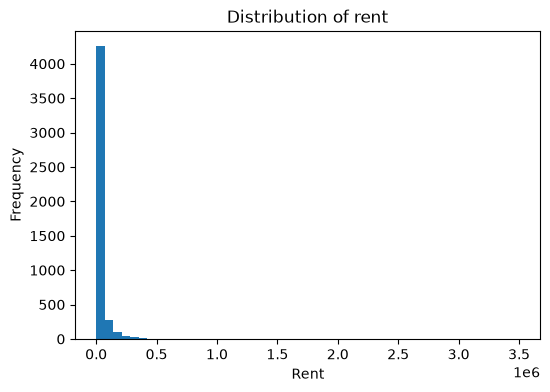

4a. Rent mean: 35009.99789162977
Rent median: 16000.0

The distribution is right-skewed, with unusually expensive listings pulling the
mean above the median. Normality of the raw observations is strained; the large
sample size helps the mean-based test but does not remove the influence of
extreme observations or make the data symmetric.



In [27]:

plt.figure(figsize=(6, 4))
plt.hist(rent["Rent"].dropna(), bins=50)
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.title("Distribution of rent")
plt.show()

print("4a. Rent mean:", rent.Rent.mean())
print("Rent median:", rent.Rent.median())
print("""
The distribution is right-skewed, with unusually expensive listings pulling the
mean above the median. Normality of the raw observations is strained; the large
sample size helps the mean-based test but does not remove the influence of
extreme observations or make the data symmetric.
""")

Part b. Redo the Problem 3a comparison three ways, all of them $t$-tests: on the raw
`Rent`, on $\log(\text{Rent})$, and on the raw rents after dropping the most extreme 1% of
listings. Report all three and explain what each one is actually estimating, and why they do not
answer quite the same question. (We get a fourth and better way, the bootstrap, in Unit 10.)

In [28]:
raw_test = stats.ttest_ind(furnished, unfurnished, equal_var=False)
log_f = np.log(furnished)
log_u = np.log(unfurnished)
log_test = stats.ttest_ind(log_f, log_u, equal_var=False)

cut_low, cut_high = rent.Rent.quantile([.01, .99])
trimmed = rent[rent.Rent.between(cut_low, cut_high)]
tf = trimmed.loc[trimmed.FurnishingStatus == "Furnished", "Rent"]
tu = trimmed.loc[trimmed.FurnishingStatus == "Unfurnished", "Rent"]
trim_test = stats.ttest_ind(tf, tu, equal_var=False)

print("4b. Raw rents: difference =", furnished.mean() - unfurnished.mean(),
      "p =", raw_test.pvalue)
print("Log rents: difference in mean logs =", log_f.mean() - log_u.mean(),
      "p =", log_test.pvalue)
print("Trimmed raw rents: difference =", tf.mean() - tu.mean(),
      "p =", trim_test.pvalue)
print("""
The raw analysis estimates an arithmetic mean-rent difference and is sensitive
to expensive listings. The log analysis compares average log rents, which is
closely related to a ratio of typical rents. Trimming estimates the difference
among listings after excluding the most extreme 1%, so these analyses answer
different questions.
""")

4b. Raw rents: difference = 33690.7800990555 p = 2.9025866170815548e-24
Log rents: difference in mean logs = 0.7774106196498742 p = 4.208098545655751e-61
Trimmed raw rents: difference = 28140.22772900646 p = 1.4394564227630846e-31

The raw analysis estimates an arithmetic mean-rent difference and is sensitive
to expensive listings. The log analysis compares average log rents, which is
closely related to a ratio of typical rents. Trimming estimates the difference
among listings after excluding the most extreme 1%, so these analyses answer
different questions.



Part c. Now the `bikes` data. Compute the lag-1 autocorrelation of `Count` across the
year (`bikes["Count"].autocorr(1)`). Report it and explain what it means about the independence
assumption behind Problem 2.

In [29]:
rho = bikes["Count"].autocorr(1)
print("4c. Bike-count lag-1 autocorrelation:", rho)
print("""
A nonzero autocorrelation means nearby days are not independent. Consequently,
the standard errors and p-value from a simple two-group t-test may be
miscalibrated.
""")


4c. Bike-count lag-1 autocorrelation: 0.500500830324923

A nonzero autocorrelation means nearby days are not independent. Consequently,
the standard errors and p-value from a simple two-group t-test may be
miscalibrated.



Part d. Demonstrate the damage by simulation: generate two groups of 200 "days" each with
**no real difference** but with each day correlated with the previous one (for example
$x_t = 0.5x_{t-1} + \varepsilon_t$). Across 2,000 such experiments, what fraction produce
$p < 0.05$? Compare it to the 5% you asked for.

In [30]:
def ar1_group(n, phi=.5):
    e = rng.normal(size=n)
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi * x[i - 1] + e[i]
    return x

dependent_hits = []
for _ in range(2000):
    a = ar1_group(200)
    b = ar1_group(200)
    dependent_hits.append(stats.ttest_ind(b, a, equal_var=False).pvalue < .05)

print("4d. False-positive fraction with dependent observations:",
      np.mean(dependent_hits))
print("""
The nominal rate is .05, but dependence can make the actual rate differ,
because the usual t-test treats 400 observations as more independent
information than they really are.
""")

4d. False-positive fraction with dependent observations: 0.2565

The nominal rate is .05, but dependence can make the actual rate differ,
because the usual t-test treats 400 observations as more independent
information than they really are.



Part e. In 2 to 3 sentences, state which of the two problems, skew or dependence, you would worry about more in a real analysis, and why.


Dependence is usually the greater concern because it directly reduces the
effective sample size and can seriously invalidate standard errors. Skew can
often be moderated by a large sample, transformation, or robust method, whereas
dependence requires modeling time or clustering explicitly.




**Problem 5.** *What can and cannot be said.* No new computation is required here. This is the part that
separates an analyst from a calculator.

Part a. Write the two-sentence result statement you would send the operations team about
holidays and bike ridership (Problem 2). It must be honest about both what you found and what
remains unknown.


The holiday sample did not provide statistically strong evidence that mean
daily bike ridership differs between holidays and non-holidays. However, the
confidence interval includes effects that may be operationally important, so
the data do not prove that holidays have no effect.





Part b. Write the two-sentence statement you would send the property manager about
furnishing (Problem 3), including the number you would recommend and the caveat attached to it.

In [31]:

print(f"""
Furnished listings rent about {d:.2f} more on average in the raw comparison,
with a 95% CI of ({lo:.2f}, {hi:.2f}). This is an association, not a causal
furnishing premium, because furnished and unfurnished listings differ in other
characteristics.
""")





Furnished listings rent about 33690.78 more on average in the raw comparison,
with a 95% CI of (27400.50, 39981.06). This is an association, not a causal
furnishing premium, because furnished and unfurnished listings differ in other
characteristics.



Part c. For each of the following claims, say whether your analyses support it, and if
not, what evidence would be required. (i) *Holidays do not affect ridership.* (ii) *Furnishing a
unit causes rent to rise by the amount you found in Problem 3a.* (iii) *The furnishing result is
more trustworthy than the holiday result because its p-value is smaller.*


(i) Not supported as an absolute claim: a non-significant test does not prove no
effect. Evidence would require a sufficiently powered study and a narrow
confidence interval around practically negligible effects.

(ii) Not supported: the observational comparison does not establish causation.
Comparable units, adjustment for confounders, or randomized furnishing would be
needed.

(iii) Not supported: a smaller p-value mainly reflects stronger evidence against
a null under the model and may also reflect larger sample size. It does not by
itself make a result more causal or practically useful.



Part d. A colleague proposes settling the holiday question by testing every weather
variable, day type, and season in the dataset and reporting whichever comparisons come out
significant. Explain what is wrong with this, and estimate roughly how many "significant" results
they would find by chance if they ran 40 such tests on pure noise.


Testing many variables and reporting only significant results creates
multiple-testing and selective-reporting bias. With 40 independent pure-noise
tests at alpha=.05, the expected number of false positives is 40*.05 = 2,
and the probability of at least one false positive is
1 - .95**40, about 87%.




Part e. Across this assignment you used p-values, confidence intervals, effect sizes, and
power. Rank them by how useful they were for making an actual decision, and defend your
ranking in 3 to 4 sentences.


For decision-making, I would rank confidence intervals first, effect sizes
second, power third, and p-values fourth. Confidence intervals show both the
size and uncertainty of an effect, while effect sizes indicate practical
importance. Power indicates whether a non-significant result was informative
enough to detect a meaningful effect. P-values are useful evidence against a
specified null, but they do not describe practical importance, causality, or
the size of uncertainty.



